# Neural Network based HLCM example
The purpose of this notebook is to provide an example of the process of training NN HLCM.

### Contents included
- Training configurations for data and neural network
- Household segmentation example
- Training data pre-processing and train-eval split
- Training error curve visualization
- Model exports and loading

### Warning
To run this notebook, the user will need to set up an environment with all the requirements. Currently, `forecast_estimation` is a private library owned by SEMCOG. 

In [ ]:
import os
import numpy as np
import pandas as pd

from forecast_estimation.utils import add_hh_indicators, std_scaler_transform, robust_scaler_transform, min_max_scaler_transform

In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Training configurations for data and neural network

In [ ]:
# config
LOAD_DATASET = False
SKIP_TRAINED_MODEL = True
choice_column = "building_id"

# paths
model_working_path = "/mnt/RDF2050/estimation/data/models_23dec12"

data_path = '/home/da/share/urbansim/RDF2050/model_inputs/base_hdf'
var_pool_table_path = "/home/da/share/urbansim/RDF2050/model_estimation/configs_hlcm_2050_update3.xlsx"
theta_path = os.path.join(model_working_path, 'thetas/theta_la%s_%s_%s_%s.txt')
hh_path = '/mnt/RDF2050/estimation/data/hh_%s.csv'
b_path = '/mnt/RDF2050/estimation/data/all_vars_w_trend_v2/b_hlcm_full_%s.csv'
model_export_path = os.path.join(model_working_path, 'pts/lcm_nn_la%s_%s_%s_%s.pt')
model_description_path = os.path.join(model_working_path, 'model_description.yaml')

# Training Config
large_areas = [
    3, 5, 93, 99, 
    115, 125, 147, 161
]
hh_filter_columns = ["building_id", "large_area_id", "mcd_model_quota", "year_built", "residential_units"]
b_filter_columns = ["large_area_id", "mcd_model_quota", "residential_units"]

# Estimation Config
HH_SAMPLE_SIZE = 10000
ESTIMATION_SAMPLE_SIZE = 100

MAX_VARS_COUNT = 999

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-2
EPOCHS = 2000
#LOSS_FUNC = 'BCELoss'
LOSS_FUNC = 'KLDivLoss'

hh_categories = {
    #'persons': ['1p', '2p', '3p', '4pp',],
    'persons': ['no_children', 'has_children',],
    'own': ['own', 'rent',], 
    'aoh': ['lt35', 'lt65', '65p']
}

SCALER_BY_LA = {
    3: 'minmax',
    5: 'minmax',
    93: 'minmax',
    99: 'minmax',
    115: 'minmax',
    125: 'minmax',
    147: 'minmax',
    161: 'minmax',
}


## Household segmentation example

In [6]:
# Loop through each large area and perform estimation and MNL model run
# Perform estimation for the current large area
#la_id = 125
la_id = 125
run_fs = False
hh = pd.read_csv(hh_path % la_id, index_col='household_id')
b = pd.read_csv(b_path % la_id, index_col='building_id')
b = b[b.residential_units>0]

hh = add_hh_indicators(hh)

persons,own,aoh = 'has_children', 'own', 'lt35'
#persons,own,aoh = '3p', 'own', 'lt35'
#persons,own,aoh = '2p', 'own', '65p'
#persons,own,aoh = '3p', 'rent', '65p'

print(persons,own,aoh)
hh_seg = hh[(hh[persons]==1)&(hh[own]==1)&(hh[aoh]==1)]
if len(hh_seg) < 10:
    print('- passing segment due to empty population')
    assert False

adding hh indicators..
has_children own lt35


In [ ]:
vars_to_use = []
for col in b.columns:
	# dropping filter column and String columns and col with 0 std
	if b[col].dtype != 'object' and col not in b_filter_columns and b[col].std() > 0.0:
		vars_to_use.append(col)

#### List of building variables

In [8]:
len(vars_to_use)

169

In [11]:
import pprint
pprint.pp(vars_to_use)

['year_built',
 'sqft_price_nonres',
 'sqft_per_unit',
 'improvement_value',
 'land_area',
 'stories',
 'non_residential_sqft',
 'sqft_price_res',
 'market_value',
 'parcels_total_units',
 'walk_nearest_park',
 'mean_zonal_hhsize',
 'non_residential_units',
 'zones_logsum_pop_high_income',
 'zones_transit_jobs_50min',
 'nodes_walk_percent_race1',
 'nodes_walk_log_15min_shopping_jobs',
 'parcels_pct_undev',
 'parcels_max_dua',
 'st_zone_prop_race_1',
 'nodes_walk_jobs',
 'nodes_walk_sector11_jobs',
 'walk_nearest_urgentcare',
 'nodes_walk_sector8_jobs',
 'nodes_walk_retail_jobs',
 'jobs_home_based',
 'zones_logsum_job_high_income',
 'nodes_drv_log_sum_15min_shopping_jobs',
 'st_zone_prop_race_3',
 'nodes_walk_race_4_hhs',
 'nodes_walk_max_retail_far',
 'nodes_walk_percent_race4',
 'nodes_walk_race_1_hhs',
 'zones_logsum_job_mid_income',
 'nodes_walk_housing_cost',
 'nodes_walk_percent_mid_income',
 'nodes_drv_log_sum_30min_shopping_jobs',
 'nodes_walk_sector2_jobs',
 'parcels_landvalue'

In [8]:
%%time
# houseolds counts
hc = len(hh_seg)

# non-sample
b_non_sample = b[~b.index.isin(hh_seg.building_id)]

negative_sample_b_idx = np.random.choice(b_non_sample.index.values, hc, replace=False)
sample_b_idx = np.concatenate((hh_seg.building_id.values, negative_sample_b_idx))
np.random.shuffle(sample_b_idx)

sample_b = b.loc[sample_b_idx, vars_to_use]
#sample_b = b.loc[:, vars_to_use]

if SCALER_BY_LA[la_id] == 'std':
	sample_b = std_scaler_transform(sample_b)
elif SCALER_BY_LA[la_id] == 'robust':
	sample_b = robust_scaler_transform(sample_b)
elif SCALER_BY_LA[la_id] == 'minmax':
	sample_b = min_max_scaler_transform(sample_b)
else:
	# do nothing
	sample_b = sample_b

# x = sample_b.to_dict(orient='list')
target = sample_b.index.isin(hh_seg.building_id).astype('int8')


CPU times: user 203 ms, sys: 149 ms, total: 352 ms
Wall time: 352 ms


## Training data pre-processing and train-eval split

### Data splitting

In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

In [10]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=0)
train_idx = sss.split(sample_b, target)

In [11]:
trn_split,val_split = None, None
for split in train_idx:
    trn_split = split[0]
    val_split = split[1]

In [12]:
trn_df,val_df = sample_b.iloc[trn_split],sample_b.iloc[val_split]
trn_tar,val_tar = target[trn_split], target[val_split]

In [13]:
len(trn_df), len(val_df)

(32238, 3582)

#### LCM_NN implementation

In [ ]:
class LCM_NN(nn.Module):
    """
    A neural network model designed for location choice modeling using PyTorch.

    Attributes:
        hidden_layer (list): A list specifying the size of each hidden layer.
        sigmoid (nn.Module): The sigmoid activation function.
        loss_func (function): The loss function used for training the model.
        loss_values (list): A list to store the loss values during training.
        variables (list): A list to store the names of the input variables.
        input_size (int): The number of input features.
        lr (float): The learning rate.
        weight_decay (float): The weight decay (L2 regularization) parameter.
        net (nn.Module): The sequential container of layers in the neural network.
        optimizer (torch.optim.Optimizer): The optimizer for training the model.
    """
    def __init__(self, input_size, hidden_layer=[10, 10], lr=1e-2, weight_decay=0, loss_func=nn.BCELoss()):
        """
        Initializes the LCM_NN model with the given parameters.

        Parameters:
            input_size (int): The number of input features.
            hidden_layer (list of int): The sizes of the hidden layers.
            lr (float): The learning rate.
            weight_decay (float): The weight decay (L2 regularization) parameter.
            loss_func (function): The loss function to be used.
        """
        super(LCM_NN, self).__init__()

        # Training utilities
        self.hidden_layer = hidden_layer
        self.sigmoid = nn.Sigmoid()
        self.loss_func = loss_func # Binary Cross Entropy Loss
        self.loss_values = []
        self.variables = None
        self.input_size = input_size
        self.lr = lr
        self.weight_decay = weight_decay

        # net architecture setup
        layers = []
        sizes = [input_size] + hidden_layer + [1]
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i != len(sizes) - 2:  # Not the last layer
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
        self.optimizer = Adam(self.parameters(), lr=lr, weight_decay=weight_decay)
    
    def forward(self, x):
        """
        Defines the forward pass of the model.

        Parameters:
            x (tensor): The input tensor.

        Returns:
            tensor: The output tensor after passing through the model.
        """
        x = self.net(x)
        return self.sigmoid(x)

    def train_nn(self, Xdf:pd.DataFrame, y:np.array, epochs=30, silent=False):    
        """
        Trains the model using the provided dataset.

        Parameters:
            Xdf (pd.DataFrame): The input features in a pandas DataFrame.
            y (np.array): The target values in a numpy array.
            epochs (int): The number of epochs for training.
            silent (bool): If True, suppresses output during training.
        """
        self.variables = list(Xdf.columns)
        self.input_size = len(Xdf.columns)
        
        # Convert data to tensors
        t_indep = torch.tensor(Xdf.values, dtype=torch.float)
        t_dep = torch.tensor(y, dtype=torch.float).reshape(-1, 1)

        # starting loss
        print('Initial Loss: %.4f' % self.loss_func(self(t_indep), t_dep).item())
        
        for epoch in range(epochs):
            # Forward pass
            predictions = self(t_indep)
            loss = self.loss_func(predictions, t_dep)
            
            # Backward pass and optimization
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            self.loss_values.append(loss.item())
            if not silent:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
        print('Final Training Loss: %.4f' % loss.item())
                
    def predict(self, Xdf):
        """
        Predicts the output for the given input data.

        Parameters:
            Xdf (pd.DataFrame): The input features in a pandas DataFrame.

        Returns:
            tensor: The predicted probabilities.
        """
        # return probability given input dataframe
        with torch.no_grad():
            indep = torch.tensor(Xdf.values, dtype=torch.float)
            pred = self(indep)
        return pred

    def calc_loss(self, Xdf, target):
        """
        Calculates the loss for the given input data and targets.

        Parameters:
            Xdf (pd.DataFrame): The input features in a pandas DataFrame.
            target (np.array): The target values.

        Returns:
            float: The calculated loss value.
        """
        # calc loss
        return self.loss_func(
            self.predict(Xdf), 
            tensor(target, dtype=torch.float).reshape(-1,1)
        )
    
    def plot_loss(self):
        """
        Plots the training loss over epochs.
        """
        plt.plot(self.loss_values)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training Loss")
        plt.show()

    def save_model(self, path):
        """
        Saves the model state to a file.

        Parameters:
            path (str): The file path where the model will be saved.
        """
        state = self.state_dict()
        state['hidden_layer'] = self.hidden_layer
        state['variables'] = self.variables
        state['input_size'] = self.input_size
        state['lr'] = self.lr
        state['weight_decay'] = self.weight_decay
        torch.save(state, path)
        return

    def load_model(self, path, device=None):
        """
        Loads the model state from a file.

        Parameters:
            path (str): The file path to load the model from.
            device (torch.device, optional): The device to map the model to.
        """
        if not device:
            device = torch.device('cpu')
        state = torch.load(path, map_location=device)
        
        self.hidden_layer = state['hidden_layer']
        self.variables = state['variables']
        self.input_size = state['input_size']
        self.lr = state['lr']
        self.weight_decay = state['weight_decay']

        # load trained params
        train_params = {k:state[k] for k in state if k.split('.')[0] == 'net'}
        self.load_state_dict(train_params)
        return
        


#### LCM_NN

In [14]:
from forecast_estimation.models.LCM_torch import LCM_NN
import torch.nn as nn
import torch
from torch import tensor

In [15]:
def combined_loss(output, target):
    mse_loss = nn.BCELoss()
    bce_loss = nn.KLDivLoss()
    w1, w2 = 1.0, 0.0
    # Calculate each loss
    loss1 = mse_loss(output, target)
    loss2 = bce_loss(output, target)
    return w1 * loss1 + w2 * loss2
    

In [16]:
N, M = trn_df.shape
print(N, M)
#lcm = LCM_NN( M, hidden_layer=[30,20], lr=1e-3, weight_decay=1e-2, loss_func=nn.BCELoss())
#lcm = LCM_NN( M, hidden_layer=[30,20], lr=1e-4, weight_decay=3e-2, loss_func=nn.KLDivLoss())
# lcm = LCM_NN( M, hidden_layer=[30,20], lr=3e-4, weight_decay=1e-2, loss_func=combined_loss)
lcm = LCM_NN( M, hidden_layer=[30,20], lr=3e-4, weight_decay=1e-2, loss_func=combined_loss)

32238 169


In [17]:
trn_tar.shape

(32238,)

In [18]:
lcm.train_nn(trn_df, trn_tar, epochs=3000, silent=False)

/home/user/micromamba/lib/python3.11/site-packages/torch/nn/functional.py:2919: UserWarning: reduction: 'mean' divides the total loss by both the batch size and the support size.'batchmean' divides only by the batch size, and aligns with the KL div math definition.'mean' will be changed to behave the same as 'batchmean' in the next major release.
  warnings.warn(


Initial Loss: 0.6946
Epoch 1/3000, Loss: 0.6946
Epoch 2/3000, Loss: 0.6945
Epoch 3/3000, Loss: 0.6943
Epoch 4/3000, Loss: 0.6942
Epoch 5/3000, Loss: 0.6940
Epoch 6/3000, Loss: 0.6939
Epoch 7/3000, Loss: 0.6938
Epoch 8/3000, Loss: 0.6937
Epoch 9/3000, Loss: 0.6936
Epoch 10/3000, Loss: 0.6935
Epoch 11/3000, Loss: 0.6934
Epoch 12/3000, Loss: 0.6933
Epoch 13/3000, Loss: 0.6932
Epoch 14/3000, Loss: 0.6931
Epoch 15/3000, Loss: 0.6930
Epoch 16/3000, Loss: 0.6929
Epoch 17/3000, Loss: 0.6929
Epoch 18/3000, Loss: 0.6928
Epoch 19/3000, Loss: 0.6927
Epoch 20/3000, Loss: 0.6927
Epoch 21/3000, Loss: 0.6926
Epoch 22/3000, Loss: 0.6925
Epoch 23/3000, Loss: 0.6925
Epoch 24/3000, Loss: 0.6924
Epoch 25/3000, Loss: 0.6923
Epoch 26/3000, Loss: 0.6922
Epoch 27/3000, Loss: 0.6922
Epoch 28/3000, Loss: 0.6921
Epoch 29/3000, Loss: 0.6920
Epoch 30/3000, Loss: 0.6919
Epoch 31/3000, Loss: 0.6919
Epoch 32/3000, Loss: 0.6918
Epoch 33/3000, Loss: 0.6918
Epoch 34/3000, Loss: 0.6917
Epoch 35/3000, Loss: 0.6916
Epoch 36

## Training error curve visualization

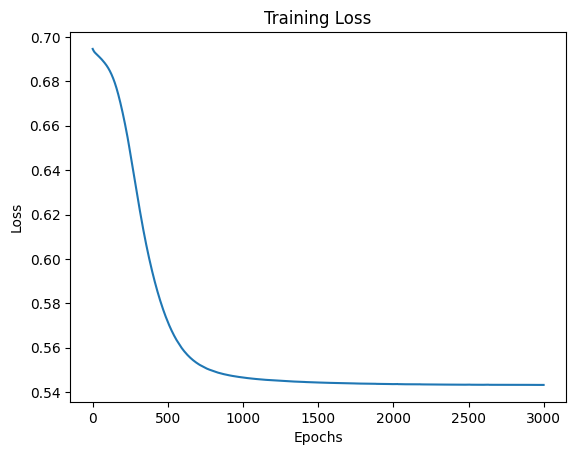

In [19]:
lcm.plot_loss()

In [57]:
print('Eval loss %.4f' % lcm.calc_loss(val_df, val_tar))

Eval loss 0.5230


## Model exports and loading

In [139]:
model_path = 'data/lcm.pt'

In [140]:
lcm.save_model(model_path)

In [141]:
device = torch.device('cuda')
state = torch.load('data/lcm.pt', map_location=device)

In [142]:
lcm2 = LCM_NN( state['input_size'], hidden_layer=state['hidden_layer'], lr=state['lr'], weight_decay=state['weight_decay'])

In [143]:
lcm2.load_model(model_path)